In [68]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import seaborn as sns
import matplotlib.pyplot as plt
import re


In [69]:
train_df = pd.read_csv("/home/rashid/Documents/FYP/Ai-Augumented-IDS/data/final/train.csv")
test_df = pd.read_csv("/home/rashid/Documents/FYP/Ai-Augumented-IDS/data/final/test.csv")

print("Dataset shape:", train_df.shape)
print("\nColumns in new dataset:")
print(train_df.columns.tolist())

print("\n=== Label Distribution ===")
print(train_df['label'].value_counts())
print("\nNormalized:")
print(train_df['label'].value_counts(normalize=True).round(4))

print("\nFirst 5 rows preview:")
print(train_df.head())

Dataset shape: (48852, 54)

Columns in new dataset:
['url_length', 'url_path_depth', 'url_num_dots', 'url_num_special', 'url_num_hyphens', 'url_num_underscores', 'url_num_percent', 'url_num_equal', 'url_num_ampersand', 'url_entropy', 'url_has_risky_ext', 'url_has_double_encoding', 'query_length', 'query_num_params', 'query_num_equals', 'query_num_special', 'query_num_percent', 'query_entropy', 'query_has_sqli', 'query_has_xss', 'query_has_traversal', 'query_has_encoding', 'query_is_empty', 'body_length', 'body_entropy', 'body_num_params', 'body_num_special', 'body_num_percent', 'body_num_quotes', 'body_num_semicolons', 'body_num_brackets', 'body_has_sqli', 'body_has_xss', 'body_has_traversal', 'body_has_encoding', 'body_is_empty', 'method_get', 'method_post', 'method_put', 'method_suspicious', 'cookie_length', 'cookie_has_sqli', 'cookie_has_xss', 'cookie_is_present', 'content_type_is_form', 'content_type_is_json', 'content_type_is_none', 'connection_is_close', 'connection_keep_alive', 

In [70]:
train_cols = set(train_df.columns)
test_cols = set(test_df.columns)

print("In train but not in test:", train_cols - test_cols)
print("In test but not in train:", test_cols - train_cols)

In train but not in test: set()
In test but not in train: set()


In [71]:
feature_cols = [col for col in train_df.columns if col != 'label']


variances = train_df[feature_cols].var()
zero_var_features = variances[variances == 0].index.tolist()

print(f"\nFound {len(zero_var_features)} features with zero variance. Removing them.")
print("Zero variance features:", zero_var_features)


useful_features = variances[variances > 0].index.tolist()

print(f"Remaining useful features: {len(useful_features)}")

X = train_df[useful_features]
y = train_df['label'].astype(int)

print("\nFinal feature matrix shape:", X.shape)


Found 16 features with zero variance. Removing them.
Zero variance features: ['url_num_special', 'body_num_quotes', 'body_num_semicolons', 'body_num_brackets', 'method_suspicious', 'cookie_length', 'cookie_has_sqli', 'cookie_has_xss', 'cookie_is_present', 'content_type_is_json', 'connection_is_close', 'connection_keep_alive', 'post_no_content_type', 'get_with_body', 'post_empty_body', 'content_length_mismatch']
Remaining useful features: 37

Final feature matrix shape: (48852, 37)


In [72]:

X = train_df.drop(columns=['label'])
y = train_df['label'].astype(int)


In [73]:

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,        # 80% train, 20% validation
    stratify=y,
    random_state=42
)
print("\nTrain set shape:", X_train.shape)
print("Validation set shape: ", X_val.shape)
print("Attack ratio in train:", y_train.mean().round(4))
print("Attack ratio in test: ", y_val.mean().round(4))


Train set shape: (39081, 53)
Validation set shape:  (9771, 53)
Attack ratio in train: 0.4105
Attack ratio in test:  0.4105


In [74]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    class_weight='balanced',   
    random_state=42,
    n_jobs=-1
)

print("\nTraining Random Forest model...")
rf.fit(X_train, y_train)



Training Random Forest model...


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [75]:

y_pred = rf.predict(X_val)
y_prob = rf.predict_proba(X_val)[:, 1]

In [76]:
print("\n=== Classification Report ===")
print(classification_report(y_val, y_pred, digits=4))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_val, y_pred))

print(f"\nF1 Score: {f1_score(y_val, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_val, y_prob):.4f}")


=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9210    0.9266    0.9238      5760
           1     0.8936    0.8858    0.8897      4011

    accuracy                         0.9098      9771
   macro avg     0.9073    0.9062    0.9067      9771
weighted avg     0.9097    0.9098    0.9098      9771


=== Confusion Matrix ===
[[5337  423]
 [ 458 3553]]

F1 Score: 0.8897
ROC-AUC Score: 0.9800


In [77]:
X_test = test_df[X.columns]
y_test = test_df['label'].astype(int)

y_test_pred = rf.predict(X_test)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.92      0.93      0.92      7200
           1       0.90      0.88      0.89      5013

    accuracy                           0.91     12213
   macro avg       0.91      0.91      0.91     12213
weighted avg       0.91      0.91      0.91     12213



In [78]:
y_test_pred = rf.predict(X_test)
y_test_prob = rf.predict_proba(X_test)[:, 1]

print("\n=== TEST Classification Report ===")
print(classification_report(y_test, y_test_pred))

print("\n=== TEST Confusion Matrix ===")
print(confusion_matrix(y_test, y_test_pred))

print(f"\nTEST F1 Score: {f1_score(y_test, y_test_pred):.4f}")
print(f"TEST ROC-AUC Score: {roc_auc_score(y_test, y_test_prob):.4f}")


=== TEST Classification Report ===
              precision    recall  f1-score   support

           0       0.92      0.93      0.92      7200
           1       0.90      0.88      0.89      5013

    accuracy                           0.91     12213
   macro avg       0.91      0.91      0.91     12213
weighted avg       0.91      0.91      0.91     12213


=== TEST Confusion Matrix ===
[[6692  508]
 [ 581 4432]]

TEST F1 Score: 0.8906
TEST ROC-AUC Score: 0.9791


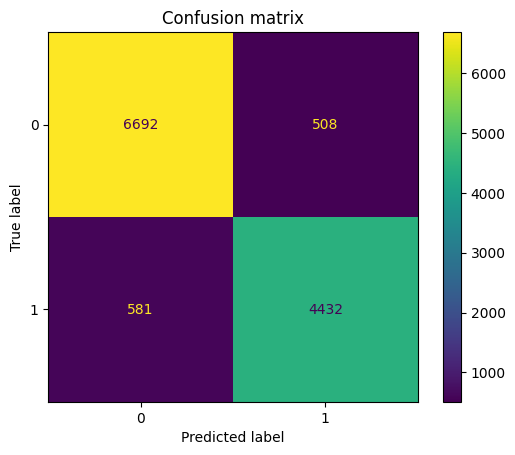

In [79]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

conf_matrix = confusion_matrix(y_test, y_test_pred, labels=rf.classes_)
display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=rf.classes_)

display.plot()
plt.title("Confusion matrix")
plt.show()